# Predicting 30-Day Hospital Readmission Using Synthetic EHR Data

This project builds a machine learning pipeline to predict whether a patient will be readmitted to the hospital within 30 days of discharge, using the Synthea synthetic electronic health record (EHR) dataset. We compare classical ML models (Logistic Regression, Random Forest, XGBoost) against a dense neural network.

**Dataset:** [Synthea](https://synthetichealth.github.io/synthea/) — 1,000+ synthetic patients with full medical histories including encounters, diagnoses, medications, labs, and procedures.

# Setup

In [1]:
%pip install polars pyarrow scikit-learn tensorflow matplotlib pandas xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import pandas as pd
import sqlite3
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta

# 1. Data Loading

The Synthea dataset consists of 16 CSV files representing a relational EHR database. Each table captures a different domain of the patient record.

In [3]:
DATA_DIR = r"C:\Users\15021\Desktop\UCSF\Python\csv"

tables = {}
for f in os.listdir(DATA_DIR):
    if f.endswith(".csv"):
        name = f.replace(".csv", "")
        tables[name] = pl.read_csv(os.path.join(DATA_DIR, f))

summary = pl.DataFrame({
    "Table": sorted(tables.keys()),
    "Rows": [tables[k].shape[0] for k in sorted(tables.keys())],
    "Columns": [tables[k].shape[1] for k in sorted(tables.keys())],
})
print(summary)

shape: (16, 3)
┌───────────────────┬───────┬─────────┐
│ Table             ┆ Rows  ┆ Columns │
│ ---               ┆ ---   ┆ ---     │
│ str               ┆ i64   ┆ i64     │
╞═══════════════════╪═══════╪═════════╡
│ allergies         ┆ 597   ┆ 6       │
│ careplans         ┆ 3483  ┆ 9       │
│ conditions        ┆ 8376  ┆ 6       │
│ devices           ┆ 78    ┆ 7       │
│ encounters        ┆ 53346 ┆ 15      │
│ …                 ┆ …     ┆ …       │
│ payer_transitions ┆ 3801  ┆ 5       │
│ payers            ┆ 10    ┆ 21      │
│ procedures        ┆ 34981 ┆ 8       │
│ providers         ┆ 5855  ┆ 12      │
│ supplies          ┆ 0     ┆ 6       │
└───────────────────┴───────┴─────────┘


# 2. Table Schemas

Six tables were used for this project. Below we inspect column names, data types, null counts, and sample values to understand how each table is structured.

In [4]:
key_tables = ["patients", "encounters", "conditions", "observations", "medications", "procedures"]

for name in key_tables:
    df = tables[name]
    sample_vals = []
    for c in df.columns:
        non_null = df[c].drop_nulls()
        if len(non_null) > 0:
            sample_vals.append(str(non_null.head(1).to_list()[0]))
        else:
            sample_vals.append("ALL NULL")

    schema = pl.DataFrame({
        "Column": df.columns,
        "Dtype": [str(d) for d in df.dtypes],
        "Nulls": [df[c].null_count() for c in df.columns],
        "Sample Value": sample_vals,
    })
    print(f"\n{'='*70}")
    print(f"  {name.upper()} — {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"{'='*70}")
    print(schema)


  PATIENTS — 1171 rows x 25 cols
shape: (25, 4)
┌─────────────────────┬─────────┬───────┬─────────────────────────────────┐
│ Column              ┆ Dtype   ┆ Nulls ┆ Sample Value                    │
│ ---                 ┆ ---     ┆ ---   ┆ ---                             │
│ str                 ┆ str     ┆ i64   ┆ str                             │
╞═════════════════════╪═════════╪═══════╪═════════════════════════════════╡
│ Id                  ┆ String  ┆ 0     ┆ 1d604da9-9a81-4ba9-80c2-de3375… │
│ BIRTHDATE           ┆ String  ┆ 0     ┆ 1989-05-25                      │
│ DEATHDATE           ┆ String  ┆ 1000  ┆ 2012-11-21                      │
│ SSN                 ┆ String  ┆ 0     ┆ 999-76-6866                     │
│ DRIVERS             ┆ String  ┆ 213   ┆ S99984236                       │
│ …                   ┆ …       ┆ …     ┆ …                               │
│ ZIP                 ┆ Int64   ┆ 543   ┆ 1013                            │
│ LAT                 ┆ Float64 ┆ 0    

# 3. Patient Demographics

Understanding the population composition is important because demographic variables (age, gender) will become features in our model.

In [5]:
patients = tables["patients"]

print("--- Gender Distribution ---")
print(patients["GENDER"].value_counts())

print("\n--- Race Distribution ---")
print(patients["RACE"].value_counts())

print("\n--- Ethnicity Distribution ---")
print(patients["ETHNICITY"].value_counts())

print("\n--- Marital Status Distribution ---")
print(patients["MARITAL"].value_counts())

print(f"\n--- Alive vs Deceased ---")
alive = patients.filter(pl.col("DEATHDATE").is_null()).height
deceased = patients.filter(pl.col("DEATHDATE").is_not_null()).height
print(f"Alive: {alive}, Deceased: {deceased}")

--- Gender Distribution ---
shape: (2, 2)
┌────────┬───────┐
│ GENDER ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ F      ┆ 609   │
│ M      ┆ 562   │
└────────┴───────┘

--- Race Distribution ---
shape: (5, 2)
┌────────┬───────┐
│ RACE   ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ native ┆ 13    │
│ black  ┆ 101   │
│ white  ┆ 965   │
│ asian  ┆ 90    │
│ other  ┆ 2     │
└────────┴───────┘

--- Ethnicity Distribution ---
shape: (2, 2)
┌─────────────┬───────┐
│ ETHNICITY   ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ nonhispanic ┆ 1058  │
│ hispanic    ┆ 113   │
└─────────────┴───────┘

--- Marital Status Distribution ---
shape: (3, 2)
┌─────────┬───────┐
│ MARITAL ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ null    ┆ 380   │
│ M       ┆ 638   │
│ S       ┆ 153   │
└─────────┴───────┘

--- Alive vs Deceased ---
Alive: 1000, Deceased: 171


# 4. Healthcare Encounters

Each row is a healthcare visit. The `ENCOUNTERCLASS` field is critical — our readmission outcome is defined on **inpatient** and **emergency** encounters only.

In [6]:
encounters = tables["encounters"]

print("--- Encounter Class Distribution ---")
print(encounters["ENCOUNTERCLASS"].value_counts().sort("count", descending=True))

print("\n--- Top 10 Encounter Reasons ---")
print(
    encounters.filter(pl.col("REASONDESCRIPTION").is_not_null())
    ["REASONDESCRIPTION"].value_counts()
    .sort("count", descending=True)
    .head(10)
)

print("\n--- Date Range ---")
print(f"Earliest: {encounters['START'].sort().head(1).item()}")
print(f"Latest:   {encounters['START'].sort(descending=True).head(1).item()}")

--- Encounter Class Distribution ---
shape: (6, 2)
┌────────────────┬───────┐
│ ENCOUNTERCLASS ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ wellness       ┆ 19106 │
│ ambulatory     ┆ 18936 │
│ outpatient     ┆ 9003  │
│ urgentcare     ┆ 2373  │
│ emergency      ┆ 2090  │
│ inpatient      ┆ 1838  │
└────────────────┴───────┘

--- Top 10 Encounter Reasons ---
shape: (10, 2)
┌─────────────────────────────────┬───────┐
│ REASONDESCRIPTION               ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Normal pregnancy                ┆ 3779  │
│ Hyperlipidemia                  ┆ 2273  │
│ Viral sinusitis (disorder)      ┆ 1378  │
│ Acute viral pharyngitis (disor… ┆ 691   │
│ Acute bronchitis (disorder)     ┆ 690   │
│ Chronic congestive heart failu… ┆ 620   │
│ Malignant neoplasm of breast (… ┆ 585   │
│ Child attention deficit disord… ┆ 287   │
│ Si

# 5. Conditions (Diagnoses)

Diagnoses coded in SNOMED-CT. The top conditions here inform which comorbidity flags created as features — conditions like hypertension, diabetes, and COPD are readmission risk factors.

In [7]:
conditions = tables["conditions"]

print("--- Top 15 Most Common Conditions ---")
print(
    conditions["DESCRIPTION"].value_counts()
    .sort("count", descending=True)
    .head(15)
)

print(f"\n--- Unique Conditions: {conditions['DESCRIPTION'].n_unique()} ---")
print(f"--- Unique Patients with Conditions: {conditions['PATIENT'].n_unique()} ---")

--- Top 15 Most Common Conditions ---
shape: (15, 2)
┌─────────────────────────────────┬───────┐
│ DESCRIPTION                     ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Viral sinusitis (disorder)      ┆ 1248  │
│ Acute viral pharyngitis (disor… ┆ 653   │
│ Acute bronchitis (disorder)     ┆ 563   │
│ Normal pregnancy                ┆ 516   │
│ Body mass index 30+ - obesity … ┆ 449   │
│ …                               ┆ …     │
│ Otitis media                    ┆ 196   │
│ Streptococcal sore throat (dis… ┆ 157   │
│ Hyperlipidemia                  ┆ 136   │
│ Sprain of ankle                 ┆ 134   │
│ Polyp of colon                  ┆ 79    │
└─────────────────────────────────┴───────┘

--- Unique Conditions: 129 ---
--- Unique Patients with Conditions: 1152 ---


# 6. Observations (Labs & Vitals)

Each row is a single clinical measurement coded in LOINC. We will extract key vital signs and lab values (BMI, blood pressure, glucose, HbA1c) as features for the model.

In [8]:
observations = tables["observations"]

print("--- Top 15 Most Common Observations ---")
print(
    observations["DESCRIPTION"].value_counts()
    .sort("count", descending=True)
    .head(15)
)

print("\n--- Sample Numeric Observations ---")
numeric_obs = observations.filter(pl.col("TYPE") == "numeric")
print(
    numeric_obs.group_by("DESCRIPTION").agg([
        pl.col("VALUE").cast(pl.Float64, strict=False).mean().alias("mean"),
        pl.col("VALUE").cast(pl.Float64, strict=False).std().alias("std"),
        pl.col("UNITS").first().alias("unit"),
        pl.len().alias("n"),
    ])
    .sort("n", descending=True)
    .head(10)
)

--- Top 15 Most Common Observations ---
shape: (15, 2)
┌─────────────────────────────────┬───────┐
│ DESCRIPTION                     ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Pain severity - 0-10 verbal nu… ┆ 16820 │
│ Diastolic Blood Pressure        ┆ 12963 │
│ Systolic Blood Pressure         ┆ 12963 │
│ Body Height                     ┆ 12552 │
│ Tobacco smoking status NHIS     ┆ 12552 │
│ …                               ┆ …     │
│ QALY                            ┆ 10121 │
│ QOLS                            ┆ 10121 │
│ Potassium                       ┆ 6515  │
│ Carbon Dioxide                  ┆ 6515  │
│ Calcium                         ┆ 6515  │
└─────────────────────────────────┴───────┘

--- Sample Numeric Observations ---
shape: (10, 5)
┌─────────────────────────────────┬────────────┬───────────┬─────────┬───────┐
│ DESCRIPTION                     ┆ mean       ┆ std       ┆ unit 

# 7. Medications

Prescriptions coded in RxNorm. Medication burden (total number of active prescriptions) is a well-established predictor of readmission — polypharmacy signals clinical complexity.

In [9]:
medications = tables["medications"]

print("--- Top 15 Most Prescribed Medications ---")
print(
    medications["DESCRIPTION"].value_counts()
    .sort("count", descending=True)
    .head(15)
)

print(f"\n--- Unique Medications: {medications['DESCRIPTION'].n_unique()} ---")

--- Top 15 Most Prescribed Medications ---
shape: (15, 2)
┌─────────────────────────────────┬───────┐
│ DESCRIPTION                     ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Hydrochlorothiazide 25 MG Oral… ┆ 3954  │
│ insulin human  isophane 70 UNT… ┆ 3880  │
│ 1 ML Epoetin Alfa 4000 UNT/ML … ┆ 3388  │
│ Atenolol 50 MG / Chlorthalidon… ┆ 3347  │
│ 24 HR Metformin hydrochloride … ┆ 2895  │
│ …                               ┆ …     │
│ Warfarin Sodium 5 MG Oral Tabl… ┆ 1278  │
│ Digoxin 0.125 MG Oral Tablet    ┆ 1278  │
│ Nitroglycerin 0.4 MG/ACTUAT Mu… ┆ 1264  │
│ Verapamil Hydrochloride 40 MG   ┆ 1259  │
│ Simvastatin 20 MG Oral Tablet   ┆ 948   │
└─────────────────────────────────┴───────┘

--- Unique Medications: 134 ---


# 8. Procedures

Clinical procedures coded in SNOMED-CT. The number and complexity of prior procedures can indicate how sick a patient has been historically.

In [10]:
procedures = tables["procedures"]

print("--- Top 15 Most Common Procedures ---")
print(
    procedures["DESCRIPTION"].value_counts()
    .sort("count", descending=True)
    .head(15)
)

print(f"\n--- Unique Procedures: {procedures['DESCRIPTION'].n_unique()} ---")

--- Top 15 Most Common Procedures ---
shape: (15, 2)
┌─────────────────────────────────┬───────┐
│ DESCRIPTION                     ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Medication Reconciliation (pro… ┆ 5632  │
│ Renal dialysis (procedure)      ┆ 3389  │
│ Auscultation of the fetal hear… ┆ 2705  │
│ Evaluation of uterine fundal h… ┆ 2705  │
│ Subcutaneous immunotherapy      ┆ 1497  │
│ …                               ┆ …     │
│ Standard pregnancy test         ┆ 474   │
│ Ultrasound scan for fetal viab… ┆ 474   │
│ Depression screening            ┆ 468   │
│ Hearing examination (procedure… ┆ 328   │
│ High resolution computed tomog… ┆ 328   │
└─────────────────────────────────┴───────┘

--- Unique Procedures: 144 ---


# 9. Readmission Feasibility Check

We define **30-day readmission** as: a patient has another inpatient or emergency encounter at least 1 day after discharge (to exclude same-day transfers) and within 30 days. This check confirms we have sufficient positive cases for modeling.

In [11]:
enc = tables["encounters"].filter(
    pl.col("ENCOUNTERCLASS").is_in(["inpatient", "emergency"])
).sort(["PATIENT", "START"])

enc = enc.with_columns([
    pl.col("START").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("start_date"),
    pl.col("STOP").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("stop_date"),
])

enc = enc.with_columns(
    pl.col("start_date").shift(-1).over("PATIENT").alias("next_start")
)

enc = enc.with_columns(
    ((pl.col("next_start") - pl.col("stop_date")).dt.total_days()).alias("days_to_next")
)

# Require >= 1 day gap to exclude same-day transfers
enc = enc.with_columns(
    (pl.col("days_to_next").is_not_null() & (pl.col("days_to_next") >= 1) & (pl.col("days_to_next") <= 30))
    .cast(pl.Int8)
    .alias("readmit_30d")
)

total = enc.height
readmit = enc.filter(pl.col("readmit_30d") == 1).height
print(f"Total eligible discharges: {total}")
print(f"30-day readmissions: {readmit}")
print(f"No readmission: {total - readmit}")
print(f"Readmission rate: {readmit / total:.1%}")

Total eligible discharges: 3928
30-day readmissions: 786
No readmission: 3142
Readmission rate: 20.0%


# 10. SQL Cohort Building

CSVs are loaded into an in-memory SQLite database and use SQL window functions to construct the analytical cohort. 

In [12]:
conn = sqlite3.connect(":memory:")

for name in ["patients", "encounters", "conditions", "observations", "medications", "procedures"]:
    tables[name].to_pandas().to_sql(name, conn, index=False, if_exists="replace")

cohort_query = """
WITH inpatient_ed AS (
    SELECT
        e.Id AS encounter_id,
        e.PATIENT AS patient_id,
        e.START AS admit_date,
        e.STOP AS discharge_date,
        e.ENCOUNTERCLASS AS encounter_class,
        e.REASONDESCRIPTION AS reason,
        LEAD(e.START) OVER (PARTITION BY e.PATIENT ORDER BY e.START) AS next_admit
    FROM encounters e
    WHERE e.ENCOUNTERCLASS IN ('inpatient', 'emergency')
),
cohort AS (
    SELECT *,
        CASE
            WHEN next_admit IS NOT NULL
            AND julianday(substr(next_admit, 1, 10)) - julianday(substr(discharge_date, 1, 10)) BETWEEN 1 AND 30
            THEN 1 ELSE 0
        END AS readmit_30d
    FROM inpatient_ed
)
SELECT * FROM cohort
"""

cohort_pd = pd.read_sql(cohort_query, conn)
cohort = pl.from_pandas(cohort_pd)
print(f"Cohort size: {cohort.height} discharges")
print(f"Readmissions: {cohort.filter(pl.col('readmit_30d') == 1).height}")
print(f"No readmission: {cohort.filter(pl.col('readmit_30d') == 0).height}")

Cohort size: 3928 discharges
Readmissions: 786
No readmission: 3142


# 11. Feature Engineering

For each discharge encounter, we construct features from the patient's **prior** medical history — demographics, conditions, medications, procedures, labs, and utilization patterns. All clinical features use only data recorded **before** the index admission date to avoid data leakage.

## 11a. Demographics

In [13]:
demo = tables["patients"].select([
    pl.col("Id").alias("patient_id"),
    pl.col("BIRTHDATE").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("birthdate"),
    pl.col("GENDER"),
    pl.col("RACE"),
    pl.col("ETHNICITY"),
])

cohort = cohort.with_columns(
    pl.col("admit_date").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("admit_dt")
)

cohort = cohort.join(demo, on="patient_id", how="left")

cohort = cohort.with_columns(
    ((pl.col("admit_dt") - pl.col("birthdate")).dt.total_days() / 365.25)
    .round(1)
    .alias("age")
)

cohort = cohort.with_columns([
    (pl.col("GENDER") == "M").cast(pl.Int8).alias("is_male"),
    (pl.col("encounter_class") == "emergency").cast(pl.Int8).alias("is_emergency"),
])

print("Demographics joined.")
print(cohort.select(["patient_id", "age", "is_male", "is_emergency", "readmit_30d"]).head(5))

Demographics joined.
shape: (5, 5)
┌─────────────────────────────────┬──────┬─────────┬──────────────┬─────────────┐
│ patient_id                      ┆ age  ┆ is_male ┆ is_emergency ┆ readmit_30d │
│ ---                             ┆ ---  ┆ ---     ┆ ---          ┆ ---         │
│ str                             ┆ f64  ┆ i8      ┆ i8           ┆ i64         │
╞═════════════════════════════════╪══════╪═════════╪══════════════╪═════════════╡
│ 00185faa-2760-4218-9bf5-db301a… ┆ 14.1 ┆ 1       ┆ 0            ┆ 0           │
│ 00185faa-2760-4218-9bf5-db301a… ┆ 14.5 ┆ 1       ┆ 0            ┆ 0           │
│ 00185faa-2760-4218-9bf5-db301a… ┆ 14.7 ┆ 1       ┆ 0            ┆ 0           │
│ 00185faa-2760-4218-9bf5-db301a… ┆ 14.9 ┆ 1       ┆ 0            ┆ 0           │
│ 00185faa-2760-4218-9bf5-db301a… ┆ 15.1 ┆ 1       ┆ 0            ┆ 0           │
└─────────────────────────────────┴──────┴─────────┴──────────────┴─────────────┘


## 11b. Length of Stay

In [14]:
cohort = cohort.with_columns(
    pl.col("discharge_date").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("discharge_dt")
)

cohort = cohort.with_columns(
    ((pl.col("discharge_dt") - pl.col("admit_dt")).dt.total_days())
    .alias("length_of_stay")
)

print("Length of stay added.")
print(cohort.select(["encounter_id", "admit_dt", "discharge_dt", "length_of_stay"]).head(5))

Length of stay added.
shape: (5, 4)
┌─────────────────────────────────┬────────────┬──────────────┬────────────────┐
│ encounter_id                    ┆ admit_dt   ┆ discharge_dt ┆ length_of_stay │
│ ---                             ┆ ---        ┆ ---          ┆ ---            │
│ str                             ┆ date       ┆ date         ┆ i64            │
╞═════════════════════════════════╪════════════╪══════════════╪════════════════╡
│ c28636e9-9b93-4e2f-807f-db90b4… ┆ 2017-12-21 ┆ 2017-12-22   ┆ 1              │
│ 0404bfc5-8e8e-457e-92d3-8707f5… ┆ 2018-05-18 ┆ 2018-05-19   ┆ 1              │
│ ed0e22d8-07c4-4b2f-a943-bf3c4d… ┆ 2018-08-05 ┆ 2018-08-06   ┆ 1              │
│ c5220bb1-f4ea-4e8f-9c8c-bcf3f8… ┆ 2018-10-18 ┆ 2018-10-19   ┆ 1              │
│ ca5d4fdb-85a6-4e26-a38b-d9713a… ┆ 2018-12-31 ┆ 2019-01-01   ┆ 1              │
└─────────────────────────────────┴────────────┴──────────────┴────────────────┘


## 11c. Prior Condition Counts

Count of all diagnoses recorded **before** the index admission, not during it — to avoid data leakage from the current hospitalization.

In [15]:
cond = tables["conditions"].select([
    pl.col("PATIENT").alias("patient_id"),
    pl.col("START").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("cond_date"),
    pl.col("DESCRIPTION").alias("condition"),
])

cond_prior = cohort.select(["encounter_id", "patient_id", "admit_dt"]).join(
    cond, on="patient_id", how="left"
).filter(pl.col("cond_date") < pl.col("admit_dt"))

cond_counts = cond_prior.group_by("encounter_id").agg([
    pl.len().alias("n_conditions"),
    pl.col("condition").n_unique().alias("n_unique_conditions"),
])

cohort = cohort.join(cond_counts, on="encounter_id", how="left")
cohort = cohort.with_columns([
    pl.col("n_conditions").fill_null(0),
    pl.col("n_unique_conditions").fill_null(0),
])

print("Condition features added (prior to admission only).")
print(cohort.select(["encounter_id", "n_conditions", "n_unique_conditions"]).head(5))

Condition features added (prior to admission only).
shape: (5, 3)
┌─────────────────────────────────┬──────────────┬─────────────────────┐
│ encounter_id                    ┆ n_conditions ┆ n_unique_conditions │
│ ---                             ┆ ---          ┆ ---                 │
│ str                             ┆ u32          ┆ u32                 │
╞═════════════════════════════════╪══════════════╪═════════════════════╡
│ c28636e9-9b93-4e2f-807f-db90b4… ┆ 2            ┆ 2                   │
│ 0404bfc5-8e8e-457e-92d3-8707f5… ┆ 3            ┆ 3                   │
│ ed0e22d8-07c4-4b2f-a943-bf3c4d… ┆ 3            ┆ 3                   │
│ c5220bb1-f4ea-4e8f-9c8c-bcf3f8… ┆ 3            ┆ 3                   │
│ ca5d4fdb-85a6-4e26-a38b-d9713a… ┆ 4            ┆ 4                   │
└─────────────────────────────────┴──────────────┴─────────────────────┘


## 11d. Comorbidity Flags

Binary flags for high-risk conditions associated with readmission in the literature. Each flag checks whether the patient was ever diagnosed with the condition before the index admission.

In [16]:
comorbidity_flags = {
    "chf": ["congestive heart failure", "heart failure"],
    "copd": ["chronic obstructive bronchitis", "chronic obstructive lung disease"],
    "diabetes": ["diabetes", "prediabetes"],
    "ckd": ["chronic kidney disease", "kidney disease"],
    "hypertension": ["hypertension", "hypertensive disease"],
    "cancer": ["neoplasm", "carcinoma", "malignant"],
    "depression": ["major depression", "depressive disorder"],
    "asthma": ["asthma"],
}

cond_all = tables["conditions"].select([
    pl.col("PATIENT").alias("patient_id"),
    pl.col("START").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("cond_date"),
    pl.col("DESCRIPTION"),
])

for flag_name, keywords in comorbidity_flags.items():
    col_name = f"has_{flag_name}"
    # Case-insensitive matching
    pattern = "(?i)" + "|".join(keywords)
    matched = cohort.select(["encounter_id", "patient_id", "admit_dt"]).join(
        cond_all, on="patient_id", how="left"
    ).filter(
        (pl.col("cond_date") < pl.col("admit_dt"))
        & pl.col("DESCRIPTION").str.contains(pattern, literal=False)
    ).select("encounter_id").unique()

    cohort = cohort.with_columns(
        pl.col("encounter_id").is_in(matched["encounter_id"]).cast(pl.Int8).alias(col_name)
    )

flag_cols = [f"has_{k}" for k in comorbidity_flags.keys()]
print("Comorbidity flag prevalence (prior history only):")
for col in flag_cols:
    n = cohort.filter(pl.col(col) == 1).height
    print(f"  {col}: {n} ({n/cohort.height:.1%})")

Comorbidity flag prevalence (prior history only):
  has_chf: 203 (5.2%)
  has_copd: 22 (0.6%)
  has_diabetes: 1645 (41.9%)
  has_ckd: 540 (13.7%)
  has_hypertension: 1205 (30.7%)
  has_cancer: 1380 (35.1%)
  has_depression: 60 (1.5%)
  has_asthma: 128 (3.3%)


C:\Users\15021\AppData\Local\Temp\ipykernel_3968\292820092.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  cohort = cohort.with_columns(


## 11e. Prior Medication Counts

In [17]:
med = tables["medications"].select([
    pl.col("PATIENT").alias("patient_id"),
    pl.col("START").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("med_date"),
    pl.col("DESCRIPTION").alias("medication"),
])

med_prior = cohort.select(["encounter_id", "patient_id", "admit_dt"]).join(
    med, on="patient_id", how="left"
).filter(pl.col("med_date") < pl.col("admit_dt"))

med_counts = med_prior.group_by("encounter_id").agg([
    pl.len().alias("n_medications"),
    pl.col("medication").n_unique().alias("n_unique_medications"),
])

cohort = cohort.join(med_counts, on="encounter_id", how="left")
cohort = cohort.with_columns([
    pl.col("n_medications").fill_null(0),
    pl.col("n_unique_medications").fill_null(0),
])

print("Medication features added (prior to admission only).")
print(cohort.select(["encounter_id", "n_medications", "n_unique_medications"]).head(5))

Medication features added (prior to admission only).
shape: (5, 3)
┌─────────────────────────────────┬───────────────┬──────────────────────┐
│ encounter_id                    ┆ n_medications ┆ n_unique_medications │
│ ---                             ┆ ---           ┆ ---                  │
│ str                             ┆ u32           ┆ u32                  │
╞═════════════════════════════════╪═══════════════╪══════════════════════╡
│ c28636e9-9b93-4e2f-807f-db90b4… ┆ 1             ┆ 1                    │
│ 0404bfc5-8e8e-457e-92d3-8707f5… ┆ 2             ┆ 2                    │
│ ed0e22d8-07c4-4b2f-a943-bf3c4d… ┆ 3             ┆ 2                    │
│ c5220bb1-f4ea-4e8f-9c8c-bcf3f8… ┆ 4             ┆ 2                    │
│ ca5d4fdb-85a6-4e26-a38b-d9713a… ┆ 5             ┆ 3                    │
└─────────────────────────────────┴───────────────┴──────────────────────┘


## 11f. Prior Procedure Counts

In [18]:
proc = tables["procedures"].select([
    pl.col("PATIENT").alias("patient_id"),
    pl.col("DATE").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("proc_date"),
    pl.col("DESCRIPTION").alias("procedure"),
])

proc_prior = cohort.select(["encounter_id", "patient_id", "admit_dt"]).join(
    proc, on="patient_id", how="left"
).filter(pl.col("proc_date") < pl.col("admit_dt"))

proc_counts = proc_prior.group_by("encounter_id").agg([
    pl.len().alias("n_procedures"),
    pl.col("procedure").n_unique().alias("n_unique_procedures"),
])

cohort = cohort.join(proc_counts, on="encounter_id", how="left")
cohort = cohort.with_columns([
    pl.col("n_procedures").fill_null(0),
    pl.col("n_unique_procedures").fill_null(0),
])

print("Procedure features added (prior to admission only).")
print(cohort.select(["encounter_id", "n_procedures", "n_unique_procedures"]).head(5))

Procedure features added (prior to admission only).
shape: (5, 3)
┌─────────────────────────────────┬──────────────┬─────────────────────┐
│ encounter_id                    ┆ n_procedures ┆ n_unique_procedures │
│ ---                             ┆ ---          ┆ ---                 │
│ str                             ┆ u32          ┆ u32                 │
╞═════════════════════════════════╪══════════════╪═════════════════════╡
│ c28636e9-9b93-4e2f-807f-db90b4… ┆ 6            ┆ 2                   │
│ 0404bfc5-8e8e-457e-92d3-8707f5… ┆ 6            ┆ 2                   │
│ ed0e22d8-07c4-4b2f-a943-bf3c4d… ┆ 6            ┆ 2                   │
│ c5220bb1-f4ea-4e8f-9c8c-bcf3f8… ┆ 6            ┆ 2                   │
│ ca5d4fdb-85a6-4e26-a38b-d9713a… ┆ 7            ┆ 2                   │
└─────────────────────────────────┴──────────────┴─────────────────────┘


## 11g. Lab & Vital Sign Features

We extract the most recent value of key clinical measurements recorded **before** admission. Missing values will be imputed with training-set medians **after** the train/test split to avoid leakage.

In [19]:
obs = tables["observations"].filter(
    pl.col("TYPE") == "numeric"
).select([
    pl.col("PATIENT").alias("patient_id"),
    pl.col("ENCOUNTER").alias("obs_encounter_id"),
    pl.col("DATE").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("obs_date"),
    pl.col("DESCRIPTION"),
    pl.col("VALUE").cast(pl.Float64, strict=False),
])

key_obs = [
    "Body Mass Index",
    "Systolic Blood Pressure",
    "Diastolic Blood Pressure",
    "Heart rate",
    "Body Weight",
    "Glucose",
    "Hemoglobin A1c/Hemoglobin.total in Blood",
]

# For each cohort encounter, get the most recent prior observation
obs_filtered = obs.filter(pl.col("DESCRIPTION").is_in(key_obs))

obs_prior = cohort.select(["encounter_id", "patient_id", "admit_dt"]).join(
    obs_filtered, on="patient_id", how="left"
).filter(pl.col("obs_date") < pl.col("admit_dt"))

# Keep the most recent value per encounter per observation type
obs_latest = (
    obs_prior
    .sort("obs_date", descending=True)
    .group_by(["encounter_id", "DESCRIPTION"])
    .agg(pl.col("VALUE").first().alias("val"))
    .pivot(on="DESCRIPTION", index="encounter_id", values="val")
)

# Clean column names
obs_latest = obs_latest.rename({
    c: c.lower().replace(" ", "_").replace("/", "_").replace(".", "")
    for c in obs_latest.columns if c != "encounter_id"
})

obs_col_names = [c for c in obs_latest.columns if c != "encounter_id"]

cohort = cohort.join(obs_latest, on="encounter_id", how="left")

print("Observation features added (most recent prior to admission).")
print(f"New columns: {obs_col_names}")

Observation features added (most recent prior to admission).
New columns: ['body_mass_index', 'heart_rate', 'body_weight', 'diastolic_blood_pressure', 'hemoglobin_a1c_hemoglobintotal_in_blood', 'systolic_blood_pressure', 'glucose']


## 11h. Prior Visit History

Count of healthcare encounters in the 6 months and 1 year before the index admission, including ED and inpatient subtotals.

In [20]:
encounters_all = tables["encounters"].select([
    pl.col("PATIENT").alias("patient_id"),
    pl.col("Id").alias("enc_id"),
    pl.col("START").str.slice(0, 10).str.to_date("%Y-%m-%d").alias("enc_date"),
    pl.col("ENCOUNTERCLASS"),
])

prior_features = []
for row in cohort.iter_rows(named=True):
    pid = row["patient_id"]
    admit = row["admit_dt"]
    past = encounters_all.filter(
        (pl.col("patient_id") == pid) & (pl.col("enc_date") < admit)
    )
    past_6m = past.filter(pl.col("enc_date") >= admit - timedelta(days=180))
    past_1y = past.filter(pl.col("enc_date") >= admit - timedelta(days=365))
    prior_features.append({
        "encounter_id": row["encounter_id"],
        "n_visits_6m": past_6m.height,
        "n_visits_1y": past_1y.height,
        "n_ed_visits_1y": past_1y.filter(pl.col("ENCOUNTERCLASS") == "emergency").height,
        "n_inpatient_1y": past_1y.filter(pl.col("ENCOUNTERCLASS") == "inpatient").height,
    })

prior_df = pl.DataFrame(prior_features)
cohort = cohort.join(prior_df, on="encounter_id", how="left")

print("Prior visit features added.")
print(cohort.select(["encounter_id", "n_visits_6m", "n_visits_1y", "n_ed_visits_1y", "n_inpatient_1y"]).head(5))

Prior visit features added.
shape: (5, 5)
┌─────────────────────────────────┬─────────────┬─────────────┬────────────────┬────────────────┐
│ encounter_id                    ┆ n_visits_6m ┆ n_visits_1y ┆ n_ed_visits_1y ┆ n_inpatient_1y │
│ ---                             ┆ ---         ┆ ---         ┆ ---            ┆ ---            │
│ str                             ┆ i64         ┆ i64         ┆ i64            ┆ i64            │
╞═════════════════════════════════╪═════════════╪═════════════╪════════════════╪════════════════╡
│ c28636e9-9b93-4e2f-807f-db90b4… ┆ 1           ┆ 1           ┆ 0              ┆ 0              │
│ 0404bfc5-8e8e-457e-92d3-8707f5… ┆ 2           ┆ 2           ┆ 0              ┆ 1              │
│ ed0e22d8-07c4-4b2f-a943-bf3c4d… ┆ 1           ┆ 3           ┆ 0              ┆ 2              │
│ c5220bb1-f4ea-4e8f-9c8c-bcf3f8… ┆ 2           ┆ 4           ┆ 0              ┆ 3              │
│ ca5d4fdb-85a6-4e26-a38b-d9713a… ┆ 3           ┆ 4           ┆ 0           

# 12. Feature Matrix & Train/Test Split

We assemble all features and split by **patient ID** — ensuring the same patient's encounters never appear in both train and test sets. This prevents the model from memorizing patient-level patterns and leaking information across sets.

Lab value imputation is performed **after** the split, using training-set medians only.

In [21]:
# Remove redundant features: keep n_unique_* (drop n_conditions, n_medications, n_procedures)
# to reduce multicollinearity between total counts and unique counts
feature_cols = [
    "age", "is_male", "is_emergency", "length_of_stay",
    "n_unique_conditions",
    "n_unique_medications",
    "n_unique_procedures",
    "n_visits_6m", "n_visits_1y", "n_ed_visits_1y", "n_inpatient_1y",
    "has_chf", "has_copd", "has_diabetes", "has_ckd",
    "has_hypertension", "has_cancer", "has_depression", "has_asthma",
] + obs_col_names

print(f"Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

X = cohort.select(feature_cols).to_pandas().values
y = cohort["readmit_30d"].to_pandas().values

# Patient-level split: all encounters from one patient stay together
patient_ids = cohort["patient_id"].to_pandas().values
unique_patients = np.unique(patient_ids)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
cohort_pandas = cohort.select(["patient_id"] + feature_cols + ["readmit_30d"]).to_pandas()
train_idx, test_idx = next(gss.split(cohort_pandas, cohort_pandas["readmit_30d"], groups=cohort_pandas["patient_id"]))

X_train = cohort_pandas.iloc[train_idx][feature_cols].values
X_test = cohort_pandas.iloc[test_idx][feature_cols].values
y_train = cohort_pandas.iloc[train_idx]["readmit_30d"].values
y_test = cohort_pandas.iloc[test_idx]["readmit_30d"].values

# Impute missing lab values with TRAINING SET medians only
for col in obs_col_names:
    col_idx = feature_cols.index(col)
    train_median = np.nanmedian(X_train[:, col_idx])
    X_train[:, col_idx] = np.where(np.isnan(X_train[:, col_idx]), train_median, X_train[:, col_idx])
    X_test[:, col_idx] = np.where(np.isnan(X_test[:, col_idx]), train_median, X_test[:, col_idx])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_train_patients = len(np.unique(cohort_pandas.iloc[train_idx]["patient_id"]))
n_test_patients = len(np.unique(cohort_pandas.iloc[test_idx]["patient_id"]))

print(f"\nTrain set: {X_train.shape[0]} encounters from {n_train_patients} patients")
print(f"Test set:  {X_test.shape[0]} encounters from {n_test_patients} patients")
print(f"Train readmission rate: {y_train.mean():.1%}")
print(f"Test readmission rate:  {y_test.mean():.1%}")

Total features: 26
Features: ['age', 'is_male', 'is_emergency', 'length_of_stay', 'n_unique_conditions', 'n_unique_medications', 'n_unique_procedures', 'n_visits_6m', 'n_visits_1y', 'n_ed_visits_1y', 'n_inpatient_1y', 'has_chf', 'has_copd', 'has_diabetes', 'has_ckd', 'has_hypertension', 'has_cancer', 'has_depression', 'has_asthma', 'body_mass_index', 'heart_rate', 'body_weight', 'diastolic_blood_pressure', 'hemoglobin_a1c_hemoglobintotal_in_blood', 'systolic_blood_pressure', 'glucose']

Train set: 3067 encounters from 698 patients
Test set:  861 encounters from 175 patients
Train readmission rate: 18.8%
Test readmission rate:  24.4%


# 13. Classical ML — Cross-Validation Comparison

We train Logistic Regression, Random Forest, and XGBoost using 5-fold stratified cross-validation. All models use `class_weight="balanced"` (or equivalent) to handle the ~80/20 class imbalance during training. This is the more principled approach — the models *learn* to care about the minority class, rather than adjusting the decision threshold after the fact.

**Note:** Tree-based models (RF, XGBoost) may still show low recall at the default 0.5 threshold despite class weighting. This is a known calibration issue — ensemble averaging pushes predicted probabilities toward the center, rarely crossing 0.5. Their high AUC confirms they *rank* patients correctly; the yes/no predictions at 0.5 simply don't reflect that ranking well. This is discussed further in the limitations.

In [22]:
# class_weight="balanced" adjusts for the 80/20 class imbalance during training.
# Each model handles this differently internally: LR adjusts coefficients,
# RF adjusts bootstrap sampling, XGBoost adjusts gradients via scale_pos_weight.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, scale_pos_weight=(sum(y_train==0)/sum(y_train==1)), eval_metric="logloss", random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name}: AUC = {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression: AUC = 0.873 ± 0.019
Random Forest: AUC = 0.858 ± 0.026
XGBoost: AUC = 0.876 ± 0.027


# 14. Evaluate Best Classical Model on Test Set

In [23]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"Best model by CV AUC: {best_name}\n")

# Fit all models on full training set
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

best_model = fitted_models[best_name]

# Classification report for ALL models (default threshold = 0.5)
for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No Readmit", "Readmit"]))

Best model by CV AUC: XGBoost

--- Logistic Regression ---
              precision    recall  f1-score   support

  No Readmit       0.85      0.83      0.84       651
     Readmit       0.51      0.55      0.53       210

    accuracy                           0.76       861
   macro avg       0.68      0.69      0.69       861
weighted avg       0.77      0.76      0.76       861

--- Random Forest ---
              precision    recall  f1-score   support

  No Readmit       0.76      0.98      0.86       651
     Readmit       0.52      0.07      0.12       210

    accuracy                           0.76       861
   macro avg       0.64      0.52      0.49       861
weighted avg       0.70      0.76      0.68       861

--- XGBoost ---
              precision    recall  f1-score   support

  No Readmit       0.77      0.97      0.86       651
     Readmit       0.54      0.10      0.18       210

    accuracy                           0.76       861
   macro avg       0.65      0.

# 15. ROC Curves — Classical Models

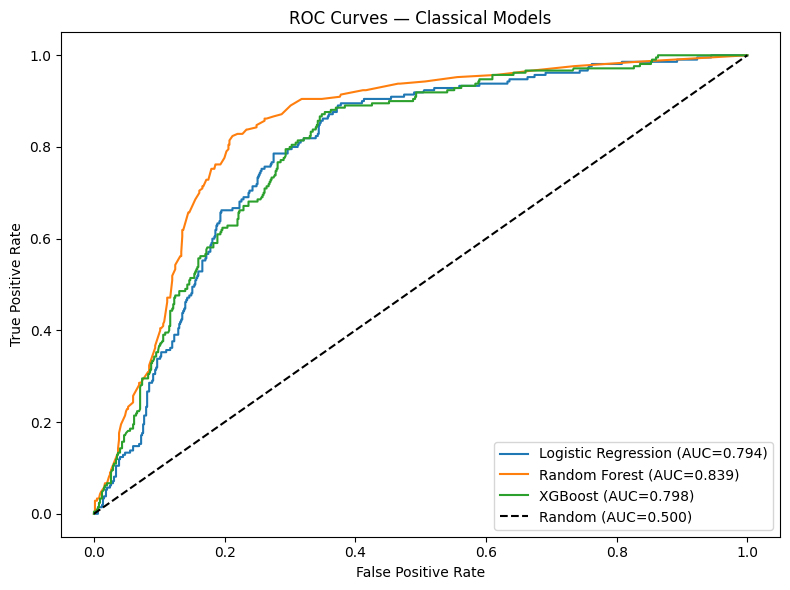

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Classical Models")
ax.legend()
plt.tight_layout()
plt.savefig("roc_classical.png", dpi=150)
plt.show()

# 16. Confusion Matrix — Best Classical Model

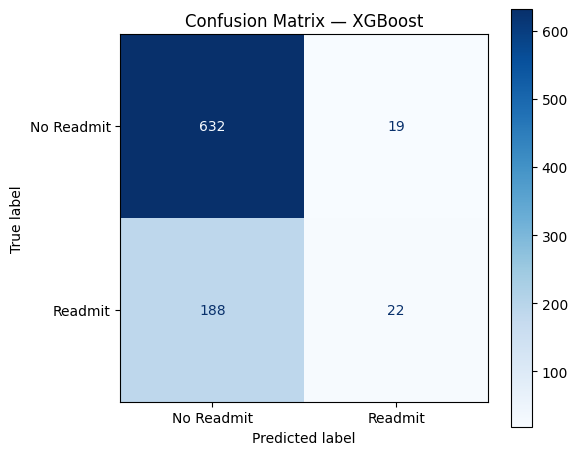

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_scaled, y_test,
    display_labels=["No Readmit", "Readmit"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("confusion_matrix_classical.png", dpi=150)
plt.show()

# 17. Feature Importance

Understanding which features drive predictions is critical for clinical interpretability. We examine Random Forest feature importances and Logistic Regression coefficients.

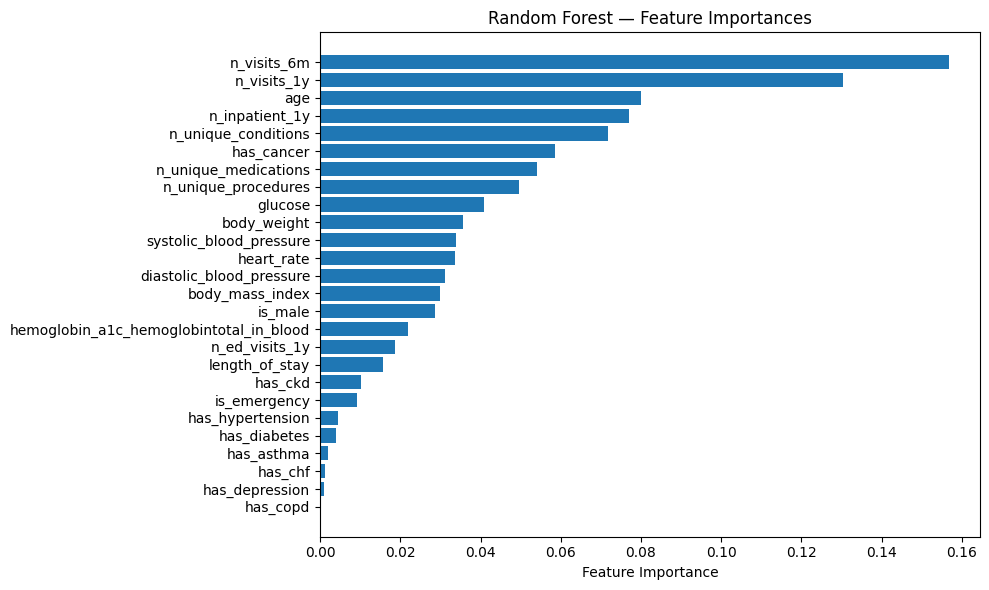


Top 10 features:
  n_visits_6m: 0.1567
  n_visits_1y: 0.1303
  age: 0.0801
  n_inpatient_1y: 0.0769
  n_unique_conditions: 0.0718
  has_cancer: 0.0585
  n_unique_medications: 0.0541
  n_unique_procedures: 0.0495
  glucose: 0.0409
  body_weight: 0.0356


In [26]:
# Random Forest feature importances
rf_model = fitted_models["Random Forest"]
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(feature_cols)), importances[sorted_idx[::-1]])
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx[::-1]])
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150)
plt.show()

print("\nTop 10 features:")
for i in sorted_idx[:10]:
    print(f"  {feature_cols[i]}: {importances[i]:.4f}")

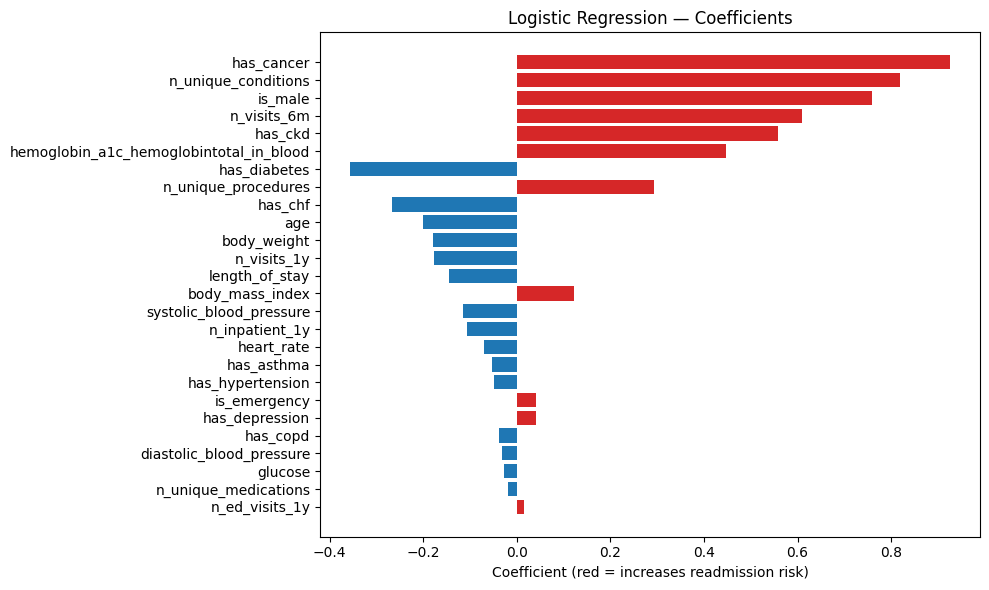


Top 10 features by absolute coefficient:
  + has_cancer: 0.9257
  + n_unique_conditions: 0.8185
  + is_male: 0.7598
  + n_visits_6m: 0.6092
  + has_ckd: 0.5589
  + hemoglobin_a1c_hemoglobintotal_in_blood: 0.4466
  - has_diabetes: -0.3563
  + n_unique_procedures: 0.2940
  - has_chf: -0.2676
  - age: -0.2004


In [27]:
# Logistic Regression coefficients
lr_model = fitted_models["Logistic Regression"]
coefs = lr_model.coef_[0]
sorted_idx_lr = np.argsort(np.abs(coefs))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coefs[sorted_idx_lr[::-1]]]
ax.barh(range(len(feature_cols)), coefs[sorted_idx_lr[::-1]], color=colors)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx_lr[::-1]])
ax.set_xlabel("Coefficient (red = increases readmission risk)")
ax.set_title("Logistic Regression — Coefficients")
plt.tight_layout()
plt.savefig("feature_importance_lr.png", dpi=150)
plt.show()

print("\nTop 10 features by absolute coefficient:")
for i in sorted_idx_lr[:10]:
    direction = "+" if coefs[i] > 0 else "-"
    print(f"  {direction} {feature_cols[i]}: {coefs[i]:.4f}")

# 18. Dense Neural Network

We build a fully connected network to compare against classical models. Note: cross-validation is not performed for the neural network due to computational cost — this is a known limitation making the comparison not strictly apples-to-apples.

In [28]:
nn_model = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid"),
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

nn_model.summary()

c:\Users\15021\Desktop\UCSF\Python\csv\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compute class weights for the neural network (same principle as class_weight="balanced")
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"Class weights: {class_weight_dict}")

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1,
)

Class weights: {0: np.float64(0.6156162183861903), 1: np.float64(2.662326388888889)}
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6925 - loss: 0.6413 - val_accuracy: 0.8322 - val_loss: 0.4184
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8168 - loss: 0.5092 - val_accuracy: 0.8306 - val_loss: 0.3940
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8259 - loss: 0.4664 - val_accuracy: 0.8436 - val_loss: 0.3810
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8324 - loss: 0.4460 - val_accuracy: 0.8208 - val_loss: 0.3935
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8381 - loss: 0.4381 - val_accuracy: 0.8322 - val_loss: 0.3805
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8317 - loss: 0.4510 - val_accuracy: 0.8290 - val_loss: 0.3874
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8340 - loss: 0.4734 - val_accuracy: 0.8388 - val_loss: 0.3651
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━

# 19. Training History

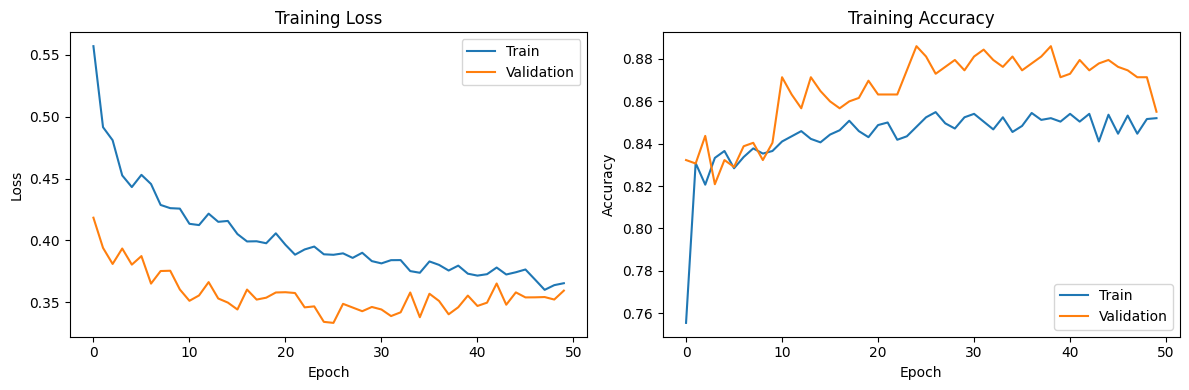

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("nn_training_history.png", dpi=150)
plt.show()

# 20. Final Comparison — All Models

We compare all four models on the test set using ROC curves and AUC, along with a classification report for the neural network.

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- Neural Network Classification Report ---
              precision    recall  f1-score   support

  No Readmit       0.86      0.86      0.86       651
     Readmit       0.56      0.57      0.57       210

    accuracy                           0.79       861
   macro avg       0.71      0.71      0.71       861
weighted avg       0.79      0.79      0.79       861



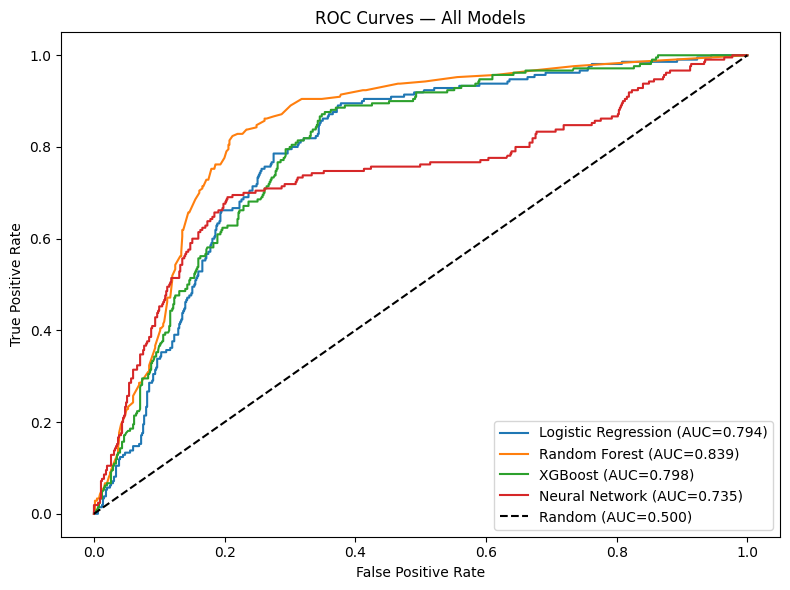


--- Test Set AUC Summary ---
Logistic Regression: 0.794
Random Forest: 0.839
XGBoost: 0.798
Neural Network: 0.735


In [31]:
# Neural network predictions (default threshold 0.5)
y_prob_nn = nn_model.predict(X_test_scaled).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

# Neural network classification report
print("--- Neural Network Classification Report ---")
print(classification_report(y_test, y_pred_nn, target_names=["No Readmit", "Readmit"]))

# ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)
ax.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC={auc_nn:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend()
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=150)
plt.show()

# Summary table
print("\n--- Test Set AUC Summary ---")
for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    print(f"{name}: {roc_auc_score(y_test, y_prob):.3f}")
print(f"Neural Network: {auc_nn:.3f}")